# Practical-2
### Done by 23AIML042

In [1]:
# Importing Required library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing with NLTK & spaCy


## Task 1: Load and Explore the Dataset

**Objective:** Understand the data structure and perform basic Exploratory Data Analysis (EDA).

In this task, we will create a read a given dataset and explore it.

1. Check first 5 rows
2. Analyse Class distribution
3. Analyse Text Length


First five rows:


,sentiment,content
0,negative,Layin n bed with a headache ughhhh...waitin o...
1,negative,Funeral ceremony...gloomy friday...
2,neutral,@dannycastillo We want to trade with someone w...
3,negative,"I should be sleep, but im not! thinking about ..."
4,negative,@charviray Charlene my love. I miss you


Summary of Data: 


,sentiment,content
count,17289,17289
unique,3,17220
top,neutral,When my grandfather died.
freq,8638,8


Null values:


sentiment    0
content      0
dtype: int64

Values count:


sentiment
neutral     8638
negative    7567
positive    1084
Name: count, dtype: int64

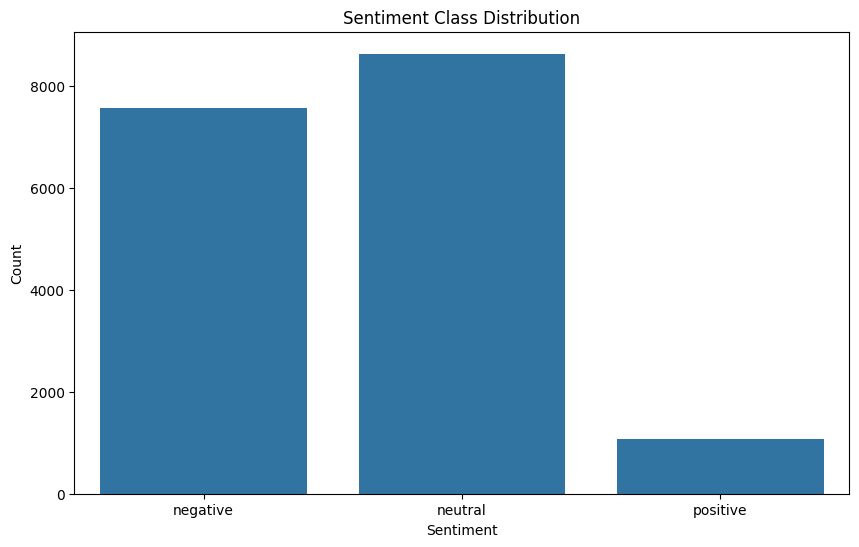

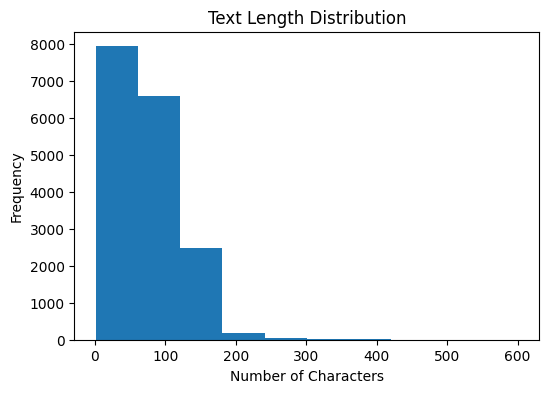

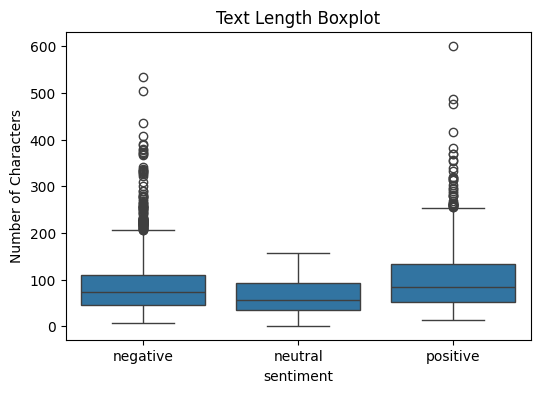

In [2]:
# load dataset
df = pd.read_csv(r"C:\Drive (D)\College\SEM. - 6\DLNLP\Dataset\emo_text.csv")

# 1.1 Read dataset
print("First five rows:")
display(df.head())

# 1.2 Basic Exploration
print("Summary of Data: ")
display(df.describe())
print("Null values:")
display(df.isnull().sum())

# 1.3 Class Distribution Analysis
print("Values count:")
display(df['sentiment'].value_counts())

plt.figure(figsize=(10,6))
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# 1.4 Text Length Analysis
df['text_length'] = df['content'].apply(len)
df[['content', 'text_length']]

plt.figure(figsize=(6,4))
plt.hist(df['text_length'], bins=10)
plt.title("Text Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='sentiment', y='text_length', data= df)
plt.title("Text Length Boxplot")
plt.ylabel("Number of Characters")
plt.show()



## Task 2: Text Pre-processing with NLTK

**Objective:** Learn the "classic" way of cleaning text using the Natural Language Toolkit (NLTK). We will cover Tokenization, Stopword Removal, and Stemming.

Write a python function `preprocess_nltk(text)` that does the following using `NLTK Library`:

1. Normalising the text (Lowercasing)
2. Tokenization (Splitting text into words)
3. Removing Punctuation and Stopwords
4. Stemming (Reducing words to their root form, e.g., "running" -> "run")

and return cleaned text

In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import string

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Initialize Stemmer and Stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_nltk(text):
    # Lowercase the text
    text = text.lower()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords and punctuation
    cleaned_tokens = []
    for word in tokens:
        if word not in stop_words and word not in string.punctuation:
            cleaned_tokens.append(word)
    
    # Stemming
    stemmed_words = [stemmer.stem(word) for word in cleaned_tokens]
    
    # Join words back to text
    return " ".join(stemmed_words)


# calling function
df['NLTK_Cleaned'] = df['content'].apply(preprocess_nltk)

print("Original vs NLTK Processed:")
display(df[['content', 'NLTK_Cleaned']].head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vedan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\vedan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vedan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original vs NLTK Processed:


,content,NLTK_Cleaned
0,Layin n bed with a headache ughhhh...waitin o...,layin n bed headach ughhhh ... waitin call ...
1,Funeral ceremony...gloomy friday...,funer ceremoni ... gloomi friday ...
2,@dannycastillo We want to trade with someone w...,dannycastillo want trade someon houston ticket...
3,"I should be sleep, but im not! thinking about ...",sleep im think old friend want 's marri damn a...
4,@charviray Charlene my love. I miss you,charviray charlen love miss


## Task 3: Advanced Pre-processing with spaCy

**Objective:** Use spaCy's industrial-strength pipeline for efficient processing, focusing on Lemmatization.

wrtie a python function `preprocess_spacy(text` that does the follwoing thing using `spacy`:

1. Create a spaCy Doc object
2. Lemmatization and stopword removal

and return cleaned text

In [4]:
import spacy

# Load the small English model
nlp = spacy.load("en_core_web_sm")

def preprocess_spacy(text):
    # Create spaCy Doc object
    doc = nlp(text.lower())
    
    # Lemmatization + Stopword Removal
    cleaned_tokens = []
    for token in doc:
        if not token.is_stop and not token.is_punct:
            cleaned_tokens.append(token.lemma_)
    
    # Join tokens back to string
    return " ".join(cleaned_tokens)

# calling fucntion
df['Spacy_Cleaned'] = df['content'].apply(preprocess_spacy)

print("NLTK (Stemmed) vs spaCy (Lemmatized):")
display(df[['NLTK_Cleaned', 'Spacy_Cleaned']].head())

NLTK (Stemmed) vs spaCy (Lemmatized):


,NLTK_Cleaned,Spacy_Cleaned
0,layin n bed headach ughhhh ... waitin call ...,layin n bed headache ughhhh waitin
1,funer ceremoni ... gloomi friday ...,funeral ceremony gloomy friday
2,dannycastillo want trade someon houston ticket...,@dannycastillo want trade houston ticket
3,sleep im think old friend want 's marri damn a...,sleep m think old friend want marry damn amp w...
4,charviray charlen love miss,@charviray charlene love miss


## Task 4: Feature Engineering (Bag of Words & TF-IDF)

**Objective:** Machines cannot understand text. We must convert text into numbers (vectors).

### 4.1 Count Vectorizer (Bag of Words)
This method counts how many times each word appears in a document.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize
count_vect = CountVectorizer()

# Fit and Transform the spaCy cleaned text
X_counts = count_vect.fit_transform(df['Spacy_Cleaned'])

# Convert to array to visualize
count_array = X_counts.toarray()
df_counts = pd.DataFrame(data=count_array, columns=count_vect.get_feature_names_out())

print("Count Vector Representation (Bag of Words):")
display(df_counts.head())

Count Vector Representation (Bag of Words):


,00,000,00am,02,023,0255,02mxjj,03,04,05,...,½u,½ulein,½ureo,½ve,½who,½why,½whyyy,½y,½z,½ï
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 4.2 TF-IDF (Term Frequency - Inverse Document Frequency)
This method highlights words that are important to a specific document but rare across the corpus (filtering out common words like "the", "is", etc., even if stopwords didn't catch them).

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize
tfidf_vect = TfidfVectorizer()

# Fit and Transform
X_tfidf = tfidf_vect.fit_transform(df['Spacy_Cleaned'])

# Convert to array to visualize
tfidf_array = X_tfidf.toarray()
df_tfidf = pd.DataFrame(data=tfidf_array, columns=tfidf_vect.get_feature_names_out())

print("TF-IDF Vector Representation:")
display(df_tfidf.head())

TF-IDF Vector Representation:


,00,000,00am,02,023,0255,02mxjj,03,04,05,...,½u,½ulein,½ureo,½ve,½who,½why,½whyyy,½y,½z,½ï
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Task 5: Sentiment Analysis Model

**Objective:** Build a Machine Learning classifier to predict sentiment based on our text features.

Write a python code that builds `MultinomiaNB` model that is trained on TF-IDF values and sentiment.

Classification Report:
              precision    recall  f1-score   support

    negative       0.61      0.73      0.66      1513
     neutral       0.74      0.70      0.72      1728
    positive       1.00      0.04      0.08       217

    accuracy                           0.67      3458
   macro avg       0.78      0.49      0.49      3458
weighted avg       0.70      0.67      0.65      3458



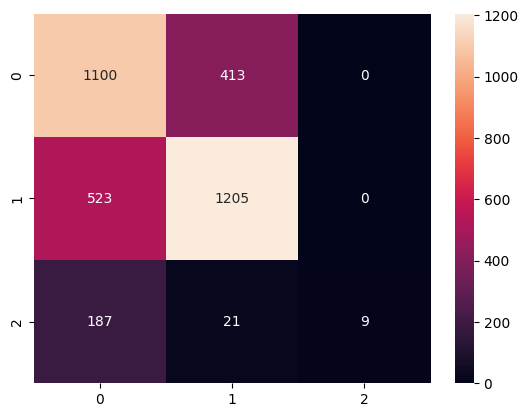

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

X = X_tfidf              # TF-IDF feature matrix
y = df['sentiment']     # Target labels


# 1. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Train Model (Naive Bayes is excellent for text)
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# 3. Predict
y_pred = nb_model.predict(X_test)

# 4. Evaluate
print("Classification Report:")
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True,fmt='d')
plt.show()

## Task 6: Interactive Prediction

**Objective:** Test the model with new, unseen user input.


Write python function `predict_sentiment(text)` that predict the sentiment of the given text by performing the following:
1. Preprocess using our defined spaCy function
2. Vectorize using the fitted TF-IDF object
3. Prediction

and returns the predicted sentiment.

In [12]:
def predict_sentiment(text):
    # 1. Preprocess text using spaCy
    cleaned_text = preprocess_spacy(text)
    
    # 2. Vectorize using trained TF-IDF
    text_vector = tfidf_vect.transform([cleaned_text])
    
    # 3. Predict sentiment
    prediction = nb_model.predict(text_vector)
    
    return prediction[0]

# Test with your own strings
new_review = "The product was okay but the delivery was very slow."
print(f"Review: '{new_review}'")
print(f"Predicted Sentiment: {predict_sentiment(new_review)}")

new_review_2 = "I absolutely loved it! Best day ever."
print(f"Review: '{new_review_2}'")
print(f"Predicted Sentiment: {predict_sentiment(new_review_2)}")

Review: 'The product was okay but the delivery was very slow.'
Predicted Sentiment: neutral
Review: 'I absolutely loved it! Best day ever.'
Predicted Sentiment: negative


# Task 7:

In [13]:
positive = df[df['sentiment'] == 'positive']
positive

,sentiment,content,text_length,NLTK_Cleaned,Spacy_Cleaned
15126,positive,"During the period of falling in love, each tim...",111,period fall love time met especi met long time,period fall love time meet especially meet lon...
15128,positive,When I got a letter offering me the Summer job...,70,got letter offer summer job appli,get letter offer summer job apply
15130,positive,On days when I feel close to my partner and ot...,163,day feel close partner friend feel peac also e...,day feel close partner friend feel peace exp...
15132,positive,After my girlfriend had taken her exam we went...,69,girlfriend taken exam went parent 's place,girlfriend take exam go parent place
15134,positive,When I pass an examination which I did not thi...,60,pass examin think well,pass examination think
...,...,...,...,...,...
17279,positive,When I received a letter from the university t...,94,receiv letter univers tell applic accept,receive letter university tell application accept
17281,positive,"I had a picnic with old classmates, we chatted...",64,picnic old classmat chat play game,picnic old classmate chat play game
17283,positive,It was the first time that I gave a birthday p...,188,first time gave birthday present friend wrote ...,time give birthday present friend write let...
17285,positive,"In August,1983, the long awaited """"big envelop...",368,"august,1983 long await `` '' big envelop '' ''...","august,1983 long await big envelope document c..."


In [14]:
positive_tweets = df[df['sentiment'] == 'positive']['Spacy_Cleaned']
from collections import Counter
word_counter = Counter()
for tweet in positive_tweets:
    words = tweet.split()
    word_counter.update(words)
    
print("Most common words in positive tweets:")
for word, freq in word_counter.most_common(10):
    print(f"{word}: {freq}")

Most common words in positive tweets:
friend: 194
get: 143
feel: 128
pass: 120
time: 112
year: 106
happy: 102
good: 96
exam: 95
joy: 94


In [17]:
test_tweet = "my friend get car!!! and fell joy and he is happy."

print("Tweet:", test_tweet)
print("Predicted Sentiment:", predict_sentiment(test_tweet))


Tweet: my friend get car!!! and fell joy and he is happy.
Predicted Sentiment: negative
